# Rescale the EOR for H6C IDR2

In this notebook I just compute the necessary rescaling as a function of redshift so that the expected EOR P(k) is at the noise level at $k=1 h/Mpc$ for the IDR2 dataset.

Our target $\Delta^2(k=1)$ is:

$$
\Delta^2(k=1) = 3000 (z / 5.6)^6,
$$

which was taken directly from the noise-level computed on the data itself.

In $P(k)$ this is 

$$
P(k=1) = \Delta^2(k=1) 2\pi^2/ k^3 \approx 6\times10^4 \left(\frac{z}{5.6}\right)^6
$$

In [1]:
import sys
sys.path.append("..")
from core import eor_utils, utils
import numpy as np


In [2]:
pspec_def = eor_utils.get_pspec_from_covariance_file(utils.SKYDIR / 'raw' / 'covariance.h5')

The power spectrum used in generating the simulations is $z$-independent, and has a magnitude of:

In [3]:
freqs = utils.FREQS_DICT['H4C']
zs = 1420e6/freqs - 1
cosmo = cosmo=eor_utils.get_planck15_cosmo()

In [17]:
unscaled_delta_sq = np.array([
    eor_utils.true_power_spectrum(
        cosmo=cosmo,
        pgps=pspec_def, 
        k = np.array([1]), 
        z=z
    ) for z in zs
]).squeeze()
    

So, to rescale the sims, we need to multiply by:

In [18]:
req = 6e4 * (zs/5.6)**6

In [19]:
scale = np.sqrt(req / unscaled_delta_sq)

In [20]:
scale

array([9766.71858305, 9663.16111985, 9560.9589673 , ...,   10.16361722,
         10.13931006,   10.1150717 ])

In [9]:
from scipy.interpolate import interp1d

In [21]:
scaler = interp1d(zs[::-1], scale[::-1]**2)

In [23]:
rescaled_delta_sq =  np.array([
    eor_utils.true_power_spectrum(
        cosmo=cosmo,
        pgps=pspec_def, 
        k = np.array([1]), 
        z=z,
        rescale_func=scaler,
    ) for z in zs
]).squeeze()

In [24]:
import matplotlib.pyplot as plt

Text(0.5, 0, 'z')

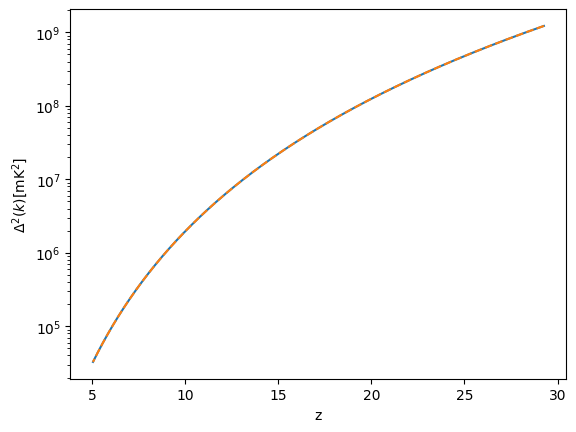

In [29]:
plt.plot(zs, rescaled_delta_sq)
plt.plot(zs, req, ls='--')
plt.yscale('log')
plt.ylabel(r"$\Delta^2(k) [{\rm mK}^2]$")
plt.xlabel("z")

In [30]:
np.save("../eor_rescaling.npy", scale)